# Practical 03: Logistic Regression – Customer Purchase Prediction

## Dataset: Social Network Ads / Purchase Dataset
## Subject: Machine Learning

Objective: Predict whether a customer will purchase a car based on Age and Estimated Salary using Logistic Regression.


## Problem Statement
A company wants to target customers likely to purchase a new car. Using past campaign data, Logistic Regression is applied for classification.

## Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

## Load Dataset

In [4]:
PurchaseData = pd.read_csv("/content/Purchase_Logistic - Purchase_Logistic.csv")
PurchaseData.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## Feature Selection

In [5]:
X = PurchaseData.iloc[:, [2,3]].values
y = PurchaseData.iloc[:,4].values

## Train Test Split

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.25,random_state=0)

## Feature Scaling

In [7]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Method 1: sklearn Logistic Regression

In [8]:
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train,y_train)

LogisticRegression(random_state=0)

## Prediction

In [9]:
y_pred = classifier.predict(X_test)

## Model Evaluation

In [10]:
cm = confusion_matrix(y_test,y_pred)
acc = accuracy_score(y_test,y_pred)

print("Confusion Matrix:\n",cm)
print("Accuracy:",acc)
print("Coefficients:",classifier.coef_)
print("Intercept:",classifier.intercept_)

Confusion Matrix:
 [[65  3]
 [ 8 24]]
Accuracy: 0.89
Coefficients: [[2.07665837 1.11008221]]
Intercept: [-0.95217247]


## Confusion Matrix Visualization

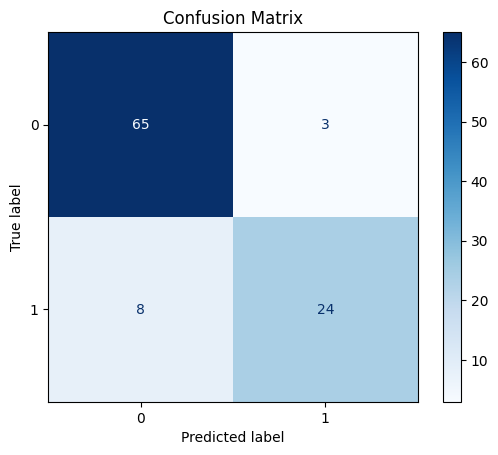

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Method 2: Logistic Regression Gradient Descent (Homework)

In [12]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

X_b = np.c_[np.ones((X_train.shape[0],1)),X_train]

theta = np.zeros(X_b.shape[1])

learning_rate = 0.1
iterations = 1000

for i in range(iterations):
    z = X_b.dot(theta)
    h = sigmoid(z)
    gradient = X_b.T.dot(h-y_train)/len(y_train)
    theta -= learning_rate*gradient

print("Theta:",theta)

Theta: [-0.98837332  2.22541241  1.19119714]


## Gradient Descent Prediction

In [13]:
X_test_b = np.c_[np.ones((X_test.shape[0],1)),X_test]

prob = sigmoid(X_test_b.dot(theta))

y_pred_gd = (prob>=0.5).astype(int)

print("Gradient Descent Accuracy:",accuracy_score(y_test,y_pred_gd))

Gradient Descent Accuracy: 0.89


## Decision Boundary (Training Set)

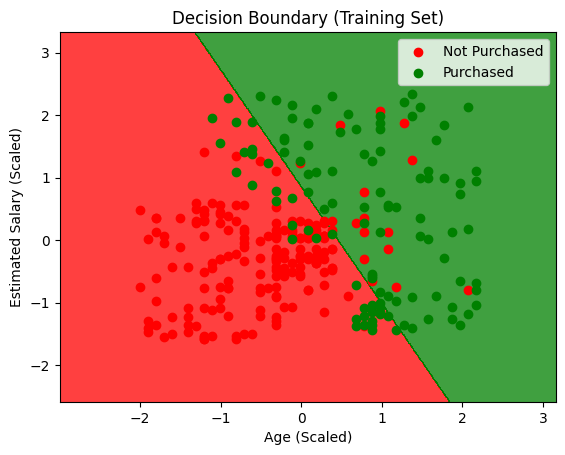

In [14]:
from matplotlib.colors import ListedColormap

X_set,y_set = X_train,y_train

X1,X2 = np.meshgrid(
np.arange(X_set[:,0].min()-1,X_set[:,0].max()+1,0.01),
np.arange(X_set[:,1].min()-1,X_set[:,1].max()+1,0.01))

plt.contourf(X1,X2,
classifier.predict(np.array([X1.ravel(),X2.ravel()]).T)
.reshape(X1.shape),
alpha=0.75,
cmap=ListedColormap(('red','green')))

plt.scatter(X_set[y_set==0,0],X_set[y_set==0,1],c='red',label='Not Purchased')
plt.scatter(X_set[y_set==1,0],X_set[y_set==1,1],c='green',label='Purchased')

plt.title("Decision Boundary (Training Set)")
plt.xlabel("Age (Scaled)")
plt.ylabel("Estimated Salary (Scaled)")
plt.legend()
plt.show()

## Conclusion

Logistic Regression successfully classified customer purchase behaviour. Feature scaling improved convergence while gradient descent demonstrated manual optimization.